In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from datetime import datetime, timedelta
import datajoint as dj

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\settings.py:979: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


In [3]:
dj.config.load("dj_local_conf_worker.json")
dj.conn()

[2026-03-26 11:13:53] Loading configuration from c:\Users\Organoid PC\Documents\GitHub\utah_organoids\dj_local_conf_worker.json
[2026-03-26 11:13:53] DataJoint 2.1.1 connected to utah-worker@db.datajoint.com:3306


DataJoint connection (connected) utah-worker@db.datajoint.com:3306

In [4]:
from workflow.pipeline import frame, culture, ephys, analysis, mua, probe, ephys_sorter

KeyError: "Setting 'custom' not found"

# Select Experiment

In [ ]:
organoid_id = "O09"
drug_name = "Control"

exp_key = {
    "organoid_id": organoid_id,
    "experiment_start_time": (culture.Experiment & f"organoid_id = '{organoid_id}'" & f"drug_name = '{drug_name}'").fetch1("experiment_start_time"),
}

culture.Experiment & exp_key

organoid_id e.g. O17,experiment_start_time,experiment_end_time,user,lineage_id de-identified code (e.g. hmau001),induction_culture_date,induction_culture_plate,post_induction_culture_date,post_induction_culture_plate,isolated_rosette_culture_date Date for isolating the rosette,isolated_rosette_culture_plate,organoid_culture_date,organoid_culture_plate,drug_name,drug_concentration concentration in uM,"experiment_plan e.g. mrna lysate, oct, protein lysate, or matrigel embedding, ephys, tracing"
O09,2023-05-03 17:33:00,2023-05-18 12:15:00,None,None,None,None,None,None,None,None,None,None,Control,nan,ephys


# Select Analysis Boundaries

In [ ]:
boundary_start = (culture.Experiment & exp_key).fetch1("experiment_start_time") + timedelta(hours=1)
boundary_end = boundary_start + timedelta(days=2)

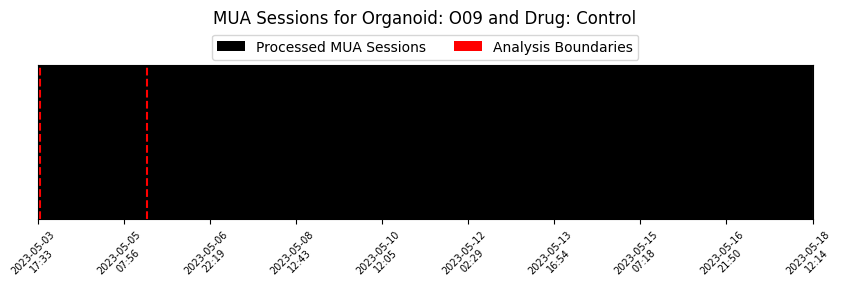

In [ ]:
def downsample_to_length(x, n_new):

    """Downsample 1D array x to length n_new using linear interpolation."""
    new_idx = np.linspace(0, x.size - 1, n_new).astype(int)
    return x[new_idx]

# determine the experiment boundaries (based on exp_key)
experiment_start_time, experiment_end_time = (culture.Experiment & exp_key).fetch1("experiment_start_time", "experiment_end_time")

# find the available files within the experiment boundaries
file_times = (ephys.EphysRawFile & exp_key & f"file_time >= '{experiment_start_time}' AND file_time < '{experiment_end_time}'").fetch("file_time")

# find the processed MUA sessions within the experiment boundaries
processed_file_times = (mua.MUAEphysSession & exp_key & f"start_time >= '{experiment_start_time}' AND start_time < '{experiment_end_time}'").fetch("start_time")

# create a visualization of the data already processed for the given exp_key
fig = plt.figure(figsize=(10, 2))
ax = fig.gca()

processed_bool = np.isin(file_times, processed_file_times)
ax.imshow(processed_bool[np.newaxis, :], aspect="auto", cmap="binary")

# plot manually selected boundaries as red vertical lines
start_x = np.searchsorted(file_times, boundary_start)
end_x = np.searchsorted(file_times, boundary_end)
ax.axvline(start_x, color="red", linestyle="--", label="Analysis Boundaries")
ax.axvline(end_x, color="red", linestyle="--")

xticks = [d.strftime('%Y-%m-%d\n%H:%M') for d in downsample_to_length(file_times, 10)]
ax.set_xticks(np.linspace(0, len(file_times) - 1, 10))
ax.set_xticklabels(xticks, rotation=45, fontsize=7)
ax.set_yticks([])

ax.set_title(f"MUA Sessions for Organoid: {organoid_id} and Drug: {drug_name}", pad=30)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='black', label='Processed MUA Sessions'), Patch(facecolor='red', label='Analysis Boundaries')]
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 2.1),
    borderaxespad=10,
    ncol=2
)

plt.show()

In [ ]:
# Check if all files within the selected boundaries have been processed
analysis_files = file_times[(file_times >= boundary_start) & (file_times <= boundary_end)]

if all(np.isin(analysis_files, processed_file_times)):
    print("All files within the selected boundaries have been processed.")
else:
    print(f"{len(analysis_files) - np.sum(np.isin(analysis_files, processed_file_times))} Files within the selected boundaries are yet to be processed.")

All files within the selected boundaries have been processed.


# Select Parameters for Frame Analysis

In [ ]:
frame.TimeFrameParamset()

frame_param_idx Unique identifier for the frame parameter set,num_frames Number of frames to extract,min_per_frame Length of each frame in minutes
1,12,5
2,4,15
3,8,15
4,24,15
5,60,5
6,8,5
7,2,5


Optional: Create Parameterset

In [ ]:
insert_key = {
    "frame_param_idx": 7,
    "num_frames": 2,
    "min_per_frame": 5
}

frame.TimeFrameParamset().insert1(insert_key, skip_duplicates=True)

## Insert New Frame Analysis Session

In [ ]:
key = {
    **exp_key,
    "start_boundary": boundary_start,
    "end_boundary": boundary_end,
    "frame_param_idx": 6
}

In [ ]:
# frame.FrameSession.insert1(key, skip_duplicates=True)
frame.FrameSession & key

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6


In [ ]:
frame.FrameAnalysis.populate(key)
frame.FrameAnalysis.ActiveTimeFrames & key

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset,frame_start Start of active time frame,frame_end End of active time frame,frame_firing_rate Firing rates for each frame
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-03 19:40:49,2023-05-03 19:45:48,1.88
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-03 20:23:49,2023-05-03 20:28:48,1.39
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-03 20:38:49,2023-05-03 20:43:48,6.75001
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-03 22:54:49,2023-05-03 22:59:48,5.79667
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-04 04:11:52,2023-05-04 04:16:51,14.9833
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-04 05:16:52,2023-05-04 05:21:51,11.2667
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-04 16:17:52,2023-05-04 16:22:51,19.4067
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-05 17:28:52,2023-05-05 17:33:51,2.55333


# Inspect Extracted Active Time Frames

In [ ]:
# Fetch MUA Firing Rates Between Boundaries
start_times, spike_rates = (mua.MUASpikes.Channel & key & f"start_time BETWEEN '{boundary_start}' AND '{boundary_end}'").fetch("start_time", "spike_rate")  

# Create population firing vector (sum spike rates across channels)
time_vector = np.arange(min(start_times), max(start_times), timedelta(minutes=1)).astype('datetime64[m]')

start_times_dt64 = start_times.astype('datetime64[m]')
population_firing_vector = np.zeros_like(time_vector, dtype=float)
for t in time_vector:

    time_bool = start_times_dt64 == t
    population_firing_vector[np.where(time_vector == t)[0][0]] = np.sum(spike_rates[time_bool])

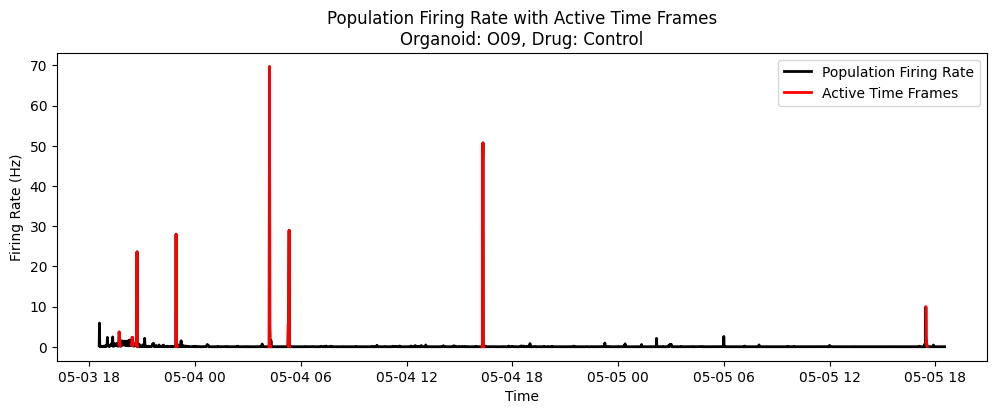

In [ ]:
# Extract Active Time Frames (sorted by firing rate)
frame_start, frame_end = (frame.FrameAnalysis.ActiveTimeFrames & key).fetch("frame_start", "frame_end", order_by="frame_start")

# Plot Population Firing Rate with Active Time Frames Highlighted in Red
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_vector, population_firing_vector, label="Population Firing Rate", color="black", linewidth=2)
for start, end in zip(frame_start, frame_end):
    active_time_mask = (np.datetime64(start, "m") <= time_vector) & (time_vector <= np.datetime64(end, "m"))
    ax.plot(time_vector[active_time_mask], population_firing_vector[active_time_mask], color="red", linewidth=2)
ax.plot([], [], color="red", label="Active Time Frames", linewidth=2)  # Dummy line for legend
ax.set_xlabel("Time")
ax.set_ylabel("Firing Rate (Hz)")
ax.set_title(f"Population Firing Rate with Active Time Frames\nOrganoid: {organoid_id}, Drug: {drug_name}")
ax.legend()
plt.show()

## Insert Analysis Tables based on Active Time Frames

In [ ]:
# Parameters for complete session analysis
insertion_number = 2 # for frame analysis
session_type = 'both'

probe_name = 'Q983'
port_id = 'A'
used_electrodes = []

burst_param_idx = 1

sorter_param_idx = 3045

spec_param_idx = 0

fooof_param_idx = 2
fbosc_param_idx = 0
start_freq = 2
end_freq = 300
analysis_electrodes = list(range((culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")))  

In [17]:
for i, (start_time, end_time) in enumerate(zip(frame_start, frame_end)):
    print(start_time, end_time)

2023-05-19 13:06:06 2023-05-19 13:11:05
2023-05-19 13:22:06 2023-05-19 13:27:05


In [18]:
frame.FrameAnalysis & "frame_param_idx IN (6, 7)"

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset,num_processed_sessions Number of sessions with available data within the analysis boundaries,num_available_files Number of available ephys files within the analysis boundaries
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2880,2880
O09,2023-05-03 17:33:00,2023-05-16 11:15:00,2023-05-18 11:15:00,6,2880,2880
O09,2023-05-18 12:25:00,2023-05-18 12:40:00,2023-05-18 16:40:00,7,240,240
O09,2023-05-18 18:15:00,2023-05-19 05:15:00,2023-05-19 09:15:00,7,240,240
O09,2023-05-19 09:30:00,2023-05-19 09:45:00,2023-05-19 13:45:00,7,240,240
O09,2023-05-19 15:45:00,2023-05-19 16:00:00,2023-05-19 20:00:00,7,240,240


In [19]:
def insert_ephys_sessions(frame_key):

    print(f"Inserting Ephys Sessions for {frame_key}")

    session_keys = (frame.FrameAnalysis.ActiveTimeFrames & frame_key).fetch("KEY")
    
    for session_key in session_keys:
        key = {
            "organoid_id": session_key["organoid_id"],
            "experiment_start_time": session_key["experiment_start_time"],
            "start_time": session_key["frame_start"],
            "end_time": session_key["frame_end"],
            "insertion_number": insertion_number,
        }

        # Ephys Session
        ephys_key = {
            **key,
            "session_type": session_type
        }
        probe_key = {
            **key,
            "probe": probe_name,
            "port_id": port_id,
            "used_electrodes": used_electrodes
        }

        ephys.EphysSession.insert1(ephys_key, skip_duplicates=True)
        ephys.EphysSessionProbe.insert1(probe_key, skip_duplicates=True)
        ephys.EphysSessionInfo.populate(key)

def insert_analysis(frame_key):

    session_keys = (frame.FrameAnalysis.ActiveTimeFrames & frame_key).fetch("KEY")
    
    for session_key in session_keys:
        key = {
            "organoid_id": session_key["organoid_id"],
            "experiment_start_time": session_key["experiment_start_time"],
            "start_time": session_key["frame_start"],
            "end_time": session_key["frame_end"],
            "insertion_number": insertion_number,
        }    

        # MUA Population Bursts
        print(f"Inserting MUA Population Burst Analysis for {key}")

        mua_key = {
            **key,
            "burst_param_idx": burst_param_idx
        }
        mua.BurstSession.insert1(mua_key, skip_duplicates=True)
        mua.PopulationBursts.populate(key)

        # Spectral Analysis
        print(f"Inserting Spectral Analysis for {key}")

        ephys.LFP.populate(key)

        trace_keys = [
            {**trace_key, "param_idx": spec_param_idx} 
            for trace_key in (ephys.LFP.Trace & key).fetch("KEY")
            ]

        analysis.LFPSpectrogram.populate(trace_keys)
        analysis.STTFA.populate(trace_keys)

        # Coherence Analysis
        print(f"Inserting Coherence Analysis for {key}")

        analysis.Coherence.populate(key)        

        # FOOOF and fBOSC analysis
        print(f"Inserting FOOOF and fBOSC Analysis for {key}")

        fooof_key = {
            **key,
            "fooof_param_idx": fooof_param_idx,
            "fbosc_param_idx": fbosc_param_idx,
            "start_freq": start_freq,
            "end_freq": end_freq,
            "analysis_electrodes": analysis_electrodes
        }
        
        analysis.FOOOFandFBOSCSession.insert1(fooof_key, skip_duplicates=True)
        analysis.FOOOFAnalysis.populate(fooof_key)

In [117]:
frame_keys = (frame.FrameAnalysis & "frame_param_idx IN (6, 7)").fetch("KEY")

for frame_key in frame_keys:
    insert_ephys_sessions(frame_key)

for frame_key in frame_keys:
    insert_analysis(frame_key)

[2026-03-13 17:38:08,195][WARNING]: Reconnecting to MySQL server.


Inserting Ephys Sessions for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'start_boundary': datetime.datetime(2023, 5, 3, 18, 33), 'end_boundary': datetime.datetime(2023, 5, 5, 18, 33), 'frame_param_idx': 6}


[2026-03-13 17:38:09,478][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 3, 19, 40, 49), 'end_time': datetime.datetime(2023, 5, 3, 19, 45, 48)}>
[2026-03-13 17:38:10,213][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 3, 20, 23, 49), 'end_time': datetime.datetime(2023, 5, 3, 20, 28, 48)}>
[2026-03-13 17:38:10,961][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 3, 20, 38, 49), 'end_time': datetime.datetime(2023, 5, 3, 20, 43, 48)}>
[2026-03-13 17:38:11,694][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_ti

Inserting Ephys Sessions for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'start_boundary': datetime.datetime(2023, 5, 16, 11, 15), 'end_boundary': datetime.datetime(2023, 5, 18, 11, 15), 'frame_param_idx': 6}


[2026-03-13 17:38:15,434][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 16, 14, 21, 5), 'end_time': datetime.datetime(2023, 5, 16, 14, 26, 4)}>
[2026-03-13 17:38:16,193][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 16, 17, 12, 5), 'end_time': datetime.datetime(2023, 5, 16, 17, 17, 4)}>
[2026-03-13 17:38:16,941][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 16, 17, 23, 5), 'end_time': datetime.datetime(2023, 5, 16, 17, 28, 4)}>
[2026-03-13 17:38:17,700][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_ti

...

[2026-03-13 20:44:49,627][INFO]: Populating ephys.LFP for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5)}>


Inserting Spectral Analysis for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5), 'insertion_number': 2}


[2026-03-13 20:45:14,165][INFO]: Populating ephys.LFP for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5)}>


Inserting Coherence Analysis for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5), 'insertion_number': 2}
Inserting FOOOF and fBOSC Analysis for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5), 'insertion_number': 2}


c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\plotly\matplotlylib\renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.

c:\users\organoid pc\documents\github\fooof\specparam\modes\funcs.py:115: RuntimeWarning:

invalid value encountered in log10



In [16]:
# insert data for each session
def insert_data(key):
    """
    key = FrameAnalysis key
    """
    for i, (start_time, end_time) in enumerate(zip(frame_start, frame_end)):

        print(f"Session {i} ({start_time} to {end_time}):")
        session_start_time = datetime.now()

        key = {
            "organoid_id": organoid_id,
            "experiment_start_time": experiment_start_time,
            "insertion_number": insertion_number,
            "start_time": start_time,
            "end_time": end_time,
        }

        # Ephys Session
        ephys_key = {
            **key,
            "session_type": session_type
        }
        probe_key = {
            **key,
            "probe": probe_name,
            "port_id": port_id,
            "used_electrodes": used_electrodes
        }

        ephys.EphysSession.insert1(ephys_key, skip_duplicates=True)
        ephys.EphysSessionProbe.insert1(probe_key, skip_duplicates=True)
        ephys.EphysSessionInfo.populate(key)

        # MUA Population Bursts
        mua_start_time = datetime.now()
        print(f"  Ephys session inserted. Time taken: {mua_start_time - session_start_time}")

        mua_key = {
            **key,
            "burst_param_idx": burst_param_idx
        }
        mua.BurstSession.insert1(mua_key, skip_duplicates=True)
        mua.PopulationBursts.populate(key)

        # Spike Sorting
        spike_sorting_start_time = datetime.now()
        print(f"  MUA population bursts inserted. Time taken: {spike_sorting_start_time - mua_start_time}")

        sua_key = {
            **key,
            "paramset_idx": sorter_param_idx
        }
        # ephys.ClusteringTask.insert1(sua_key, skip_duplicates=True)
        # ephys_sorter.PreProcessing.populate(sua_key)
        # ephys_sorter.SIClustering.populate(sua_key)
        # ephys_sorter.PostProcessing.populate(sua_key)
        # ephys.CuratedClustering.populate(sua_key)

        sua_sorting_start_time = datetime.now()
        print(f"  Spike sorting completed. Time taken: {sua_sorting_start_time - spike_sorting_start_time}")

        # ephys.WaveformSet.populate(sua_key)
        # ephys.QualityMetrics.populate(sua_key)

        sttc_start_time = datetime.now()
        print(f"  Waveforms and quality metrics populated. Time taken: {sttc_start_time - sua_sorting_start_time}")

        # ephys.STTC.populate(sua_key)

        # Spectral Analysis
        trace_start_time = datetime.now()
        print(f"  STTC populated. Time taken: {trace_start_time - sttc_start_time}")

        ephys.LFP.populate(key)

        trace_keys = [
            {**trace_key, "param_idx": spec_param_idx} 
            for trace_key in (ephys.LFP.Trace & key).fetch("KEY")
            ]
        
        spectral_start_time = datetime.now()
        print(f"  LFP traces populated. Time taken: {spectral_start_time - trace_start_time}")

        analysis.LFPSpectrogram.populate(trace_keys)
        analysis.STTFA.populate(trace_keys)

        # Coherence Analysis
        coherence_start_time = datetime.now()
        print(f"  Spectrogram and STTFA populated. Time taken: {coherence_start_time - spectral_start_time}")

        analysis.Coherence.populate(key)

        # FOOOF and fBOSC analysis
        fooof_start_time = datetime.now()
        print(f"  Coherence populated. Time taken: {fooof_start_time - coherence_start_time}")

        fooof_key = {
            **key,
            "fooof_param_idx": fooof_param_idx,
            "fbosc_param_idx": fbosc_param_idx,
            "start_freq": start_freq,
            "end_freq": end_freq,
            "analysis_electrodes": analysis_electrodes
        }
        analysis.FOOOFandFBOSCSession.insert1(fooof_key, skip_duplicates=True)
        analysis.FOOOFAnalysis.populate(fooof_key)

        session_end_time = datetime.now()
        print(f"  FOOOF and fBOSC analysis completed. Time taken: {session_end_time - fooof_start_time}")
        print(f"Total time taken for session {i}: {session_end_time - session_start_time}\n")

In [5]:
# Insert spike sorting sessions
frame_keys = (frame.FrameAnalysis.ActiveTimeFrames & "frame_param_idx = 6").fetch("KEY")

ephys_keys = [
    {
        "organoid_id": frame_key["organoid_id"],
        "experiment_start_time": frame_key["experiment_start_time"],
        "start_time": frame_key["frame_start"],
        "end_time": frame_key["frame_end"],
        "insertion_number": insertion_number,
    }
    for frame_key in frame_keys
    ]

NameError: name 'frame' is not defined

In [18]:
example_key = ephys_keys[0]
sua_key = {
    **example_key,
    "paramset_idx": 401
}

sua_key

{'organoid_id': 'O09',
 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33),
 'start_time': datetime.datetime(2023, 5, 3, 19, 40, 49),
 'end_time': datetime.datetime(2023, 5, 3, 19, 45, 48),
 'insertion_number': 2,
 'paramset_idx': 401}

In [19]:
ephys.ClusteringTask.insert1(sua_key, skip_duplicates=True)
ephys.ClusteringTask & sua_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,paramset_idx,clustering_output_dir clustering output directory relative to the clustering root data directory
O09,2023-05-03 17:33:00,2,2023-05-03 19:40:49,2023-05-03 19:45:48,401,


In [20]:
ephys_sorter.PreProcessing.populate(sua_key)

[2026-03-26 10:42:27,281][INFO]: D:\processed_data\O09-12_raw\202305031940_202305031945\O09\kilosort4_401 created!


AttributeError: 'ConcatenateSegmentRecording' object has no attribute 'channel_slice'

In [22]:
ephys_sorter.SIClustering.populate(sua_key)

FileNotFoundError: No valid full-path found (from [WindowsPath('D:/raw_data'), WindowsPath('D:/processed_data')]) for O09-12_raw\202305031940_202305031945\O09\kilosort4_401

In [26]:
# load pickle file
import pickle 
path = "C:\\Users\\Organoid PC\\Documents\\processed_data\\O09-12_raw\\202305031940_202305031945\\O09\\kilosort4_4005\\kilosort4\\recording\\si_recording.pkl"


In [27]:
import spikeinterface as si
si_recording = si.load(path)

In [28]:
traces = si_recording.get_traces()

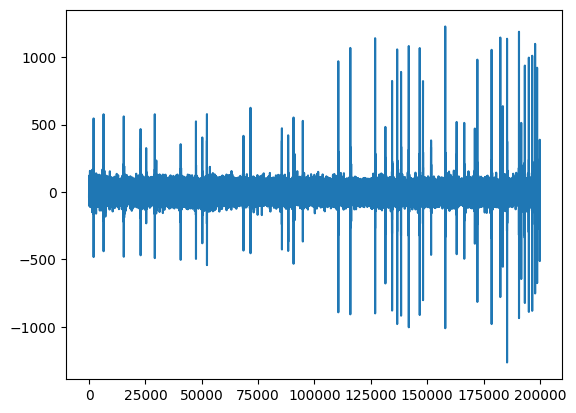

In [30]:
plt.plot(traces[1200000:1400000,8])

In [36]:
ephys.ClusteringParamSet & "paramset_idx > 400"

paramset_idx,clustering_method,paramset_desc,param_set_hash,params dictionary of all applicable parameters
401,kilosort4,Kilosort4 standard profile for 100um probe spacing,75a2f1d3-b077-78bb-3a68-b8456644a9f1,=BLOB=
403,kilosort4,"KKilosort4 conservative profile , chimera-sensitive",059d3e65-d955-d459-1d11-d2235be42a8a,=BLOB=
405,kilosort4,Paramset 401 with installation mode set to pypi for SI sorting,ecae73ee-73ba-77bf-c7e4-8cf2f7189067,=BLOB=
475,spykingcircus2,Spyking circus2 with a detection threshold 4.75 (neg direction),cc552535-6116-c01c-01fe-bfaf34fe0e7d,=BLOB=
1010,spykingcircus2,Testing insertion of new paramset,a0f9d38c-38b7-3e81-3a08-50dc2062c5dc,=BLOB=


In [24]:
params = (ephys.ClusteringParamSet & "paramset_idx = 304").fetch1("params")
params["SI_SORTING_PARAMS"]["installation_mode"] = "pypi"

params

{'SI_PREPROCESSING_METHOD': 'organoid_preprocessing',
 'SI_SORTING_PARAMS': {'detect_threshold': 5,
  'projection_threshold': [9, 9],
  'preclust_threshold': 8,
  'whiteningRange': 32,
  'car': False,
  'minFR': 0.05,
  'minfr_goodchannels': 0.05,
  'nblocks': 6,
  'sig': 20,
  'freq_min': 300,
  'sigmaMask': 30,
  'lam': 20.0,
  'nPCs': 3,
  'ntbuff': 128,
  'nfilt_factor': 4,
  'do_correction': False,
  'NT': None,
  'AUCsplit': 0.8,
  'wave_length': 61,
  'keep_good_only': False,
  'skip_kilosort_preprocessing': False,
  'scaleproc': None,
  'save_rez_to_mat': False,
  'delete_tmp_files': ('matlab_files',),
  'delete_recording_dat': False,
  'pool_engine': 'process',
  'progress_bar': True,
  'mp_context': None,
  'max_threads_per_worker': 1,
  'installation_mode': 'pypi'},
 'SI_POSTPROCESSING_PARAMS': {'extensions': {'random_spikes': {},
   'waveforms': {},
   'templates': {},
   'noise_levels': {},
   'correlograms': {},
   'isi_histograms': {},
   'principal_components': {'n_comp

In [25]:
ephys.ClusteringParamSet.insert_new_params(
    clustering_method="kilosort3",
    paramset_desc = "param 304 with installation mode = pypi",
    params = params,
    paramset_idx = 3045
)

In [23]:
(ephys.ClusteringParamSet & "paramset_idx = 3045").delete()

[2026-03-19 12:05:20,714][INFO]: Deleting 1 rows from `utah_organoids_ephys_sorter`.`_pre_processing`
[2026-03-19 12:05:21,099][INFO]: Deleting 1 rows from `utah_organoids_ephys`.`clustering_task`
[2026-03-19 12:05:21,470][INFO]: Deleting 1 rows from `utah_organoids_ephys`.`#clustering_param_set`
[2026-03-19 12:05:27,494][INFO]: Deletes committed.


1